# Seoul Bike Sharing Demand: a fair regression benchmark

<p>This notebook improves the existing benchmark while keeping its short code cells and simple explanations. The goal is to estimate the citywide number of rented bikes for each functioning hour.</p>

This project keeps two prediction contracts separate:

1. **Comparable benchmark:** calendar + recorded same-hour weather, with no past target values. This is a conditional or “oracle-weather” estimate. For a real forecast, recorded future weather must be replaced by weather forecasts.
2. **Rolling one-hour extension:** past-demand lags plus recorded same-hour weather as an oracle proxy for an assumed one-hour weather forecast. Each actual count becomes available before the next prediction. A production evaluation must replace recorded weather with archived one-hour forecasts; this setup is not valid for a fixed multi-hour batch forecast.

The service-closure schedule is treated as a known operational gate. Non-functioning hours are excluded from the demand model because every such target is structurally zero.

Dataset: [UCI Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand), DOI [10.24432/C5F62R](https://doi.org/10.24432/C5F62R), CC BY 4.0.

In [1]:
# I limit numerical libraries to one thread so the notebook runs reliably on small laptops and restricted environments.
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

In [2]:
# These are the same core libraries used in the current notebook, plus tools for timing and interpretation.
from pathlib import Path
from time import perf_counter
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

random_state = 42
sns.set_theme(style="whitegrid")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.12.0
pandas: 3.0.3
scikit-learn: 1.8.0


### Evidence behind the benchmark design

- scikit-learn explains that time-ordered data must not train on the future and evaluate on the past: [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html).
- Learned preprocessing is fitted inside pipelines to reduce leakage: [common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html).
- The official bike-demand examples motivate calendar interactions and clearly separate lagged one-step forecasting from random splitting: [time features](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html) and [lagged features](https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html).
- Recent large tabular benchmarks still find tree ensembles to be strong practical baselines; this supports testing a small MLP without assuming deep learning must win: [TabArena, NeurIPS 2025](https://papers.neurips.cc/paper_files/paper/2025/file/1697e3fb412da11dc9488249f9e7bbc9-Paper-Datasets_and_Benchmarks_Track.pdf).

<h3><center>Loading and exploring the dataset</center></h3>

In [3]:
# I use the same relative path and text encoding as the current notebook.
data_path = Path("seoul+bike+sharing+demand/SeoulBikeData.csv")
df = pd.read_csv(data_path, encoding="cp1252")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
# I validate the source schema before renaming columns, because silent column-order changes can corrupt a pipeline.
expected_columns = [
    "Date", "Rented Bike Count", "Hour", "Temperature(°C)", "Humidity(%)",
    "Wind speed (m/s)", "Visibility (10m)", "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)", "Rainfall(mm)", "Snowfall (cm)", "Seasons",
    "Holiday", "Functioning Day",
]
assert df.columns.tolist() == expected_columns, "The input schema has changed."

rename_columns = {
    "Date": "date", "Rented Bike Count": "rented_bike_count", "Hour": "hour",
    "Temperature(°C)": "temperature_c", "Humidity(%)": "humidity_percent",
    "Wind speed (m/s)": "wind_speed_m_s", "Visibility (10m)": "visibility_10m",
    "Dew point temperature(°C)": "dew_point_temperature_c",
    "Solar Radiation (MJ/m2)": "solar_radiation_mj_m2", "Rainfall(mm)": "rainfall_mm",
    "Snowfall (cm)": "snowfall_cm", "Seasons": "season", "Holiday": "holiday",
    "Functioning Day": "functioning_day",
}
df = df.rename(columns=rename_columns)
df.columns

Index(['date', 'rented_bike_count', 'hour', 'temperature_c',
       'humidity_percent', 'wind_speed_m_s', 'visibility_10m',
       'dew_point_temperature_c', 'solar_radiation_mj_m2', 'rainfall_mm',
       'snowfall_cm', 'season', 'holiday', 'functioning_day'],
      dtype='str')

In [5]:
# I build one hourly timestamp and sort it before any time-based feature is created.
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y", errors="raise")
df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")
df = df.sort_values("datetime").reset_index(drop=True)

# I create only the two lags used by the later rolling extension. They stay out of the primary benchmark.
# Lags are built before filtering; otherwise 24 rows would not always mean 24 clock hours.
df["demand_lag_1h"] = df["rented_bike_count"].shift(1)
df["demand_mean_24h"] = df["rented_bike_count"].shift(1).rolling(24).mean()

df[["datetime", "rented_bike_count", "demand_lag_1h", "demand_mean_24h"]].head(26).tail()

,datetime,rented_bike_count,demand_lag_1h,demand_mean_24h
21,2017-12-01 21:00:00,405,426.0,NaN
22,2017-12-01 22:00:00,398,405.0,NaN
23,2017-12-01 23:00:00,323,398.0,NaN
24,2017-12-02 00:00:00,328,323.0,397.458333
25,2017-12-02 01:00:00,308,328.0,400.541667


In [6]:
# These checks turn our understanding of the raw data into executable rules.
gap_hours = df["datetime"].diff().dt.total_seconds().div(3600)
quality_summary = pd.Series({
    "rows": len(df),
    "missing_raw_values": df[list(rename_columns.values())].isna().sum().sum(),
    "duplicated_rows": df[list(rename_columns.values())].duplicated().sum(),
    "duplicated_timestamps": df["datetime"].duplicated().sum(),
    "non_hourly_gaps": gap_hours.dropna().ne(1).sum(),
    "start": df["datetime"].min(),
    "end": df["datetime"].max(),
})

assert quality_summary["duplicated_timestamps"] == 0
assert quality_summary["non_hourly_gaps"] == 0
assert df["hour"].between(0, 23).all()
quality_summary

rows                                    8760
missing_raw_values                         0
duplicated_rows                            0
duplicated_timestamps                      0
non_hourly_gaps                            0
start                    2017-12-01 00:00:00
end                      2018-11-30 23:00:00
dtype: object

In [7]:
# I inspect ranges before deciding whether any value is an error.
df[[
    "rented_bike_count", "temperature_c", "humidity_percent", "wind_speed_m_s",
    "visibility_10m", "solar_radiation_mj_m2", "rainfall_mm", "snowfall_cm",
]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
rented_bike_count,8760.0,704.60,645.00,0.0,191.0,504.50,1065.25,3556.00
temperature_c,8760.0,12.88,11.94,-17.8,3.5,13.70,22.50,39.40
humidity_percent,8760.0,58.23,20.36,0.0,42.0,57.00,74.00,98.00
wind_speed_m_s,8760.0,1.72,1.04,0.0,0.9,1.50,2.30,7.40
visibility_10m,8760.0,1436.83,608.30,27.0,940.0,1698.00,2000.00,2000.00
solar_radiation_mj_m2,8760.0,0.57,0.87,0.0,0.0,0.01,0.93,3.52
rainfall_mm,8760.0,0.15,1.13,0.0,0.0,0.00,0.00,35.00
snowfall_cm,8760.0,0.08,0.44,0.0,0.0,0.00,0.00,8.80


<h3><center>Defining the operational target</center></h3>

In [8]:
# Every closure hour has zero rentals, so closure and demand are two different operational mechanisms.
closure_rows = df[df["functioning_day"].eq("No")]
closure_summary = pd.Series({
    "non_functioning_hours": len(closure_rows),
    "non_functioning_dates": closure_rows["date"].nunique(),
    "zero_target_share_during_closure": closure_rows["rented_bike_count"].eq(0).mean(),
    "all_dataset_zero_targets": df["rented_bike_count"].eq(0).sum(),
})

assert closure_rows["rented_bike_count"].eq(0).all()
closure_summary

non_functioning_hours               295.0
non_functioning_dates                13.0
zero_target_share_during_closure      1.0
all_dataset_zero_targets            295.0
dtype: float64

The raw file declares no missing values, but 17 humidity readings are exactly zero. Temperature and dew point provide an independent consistency check. NOAA publishes calculators and equations connecting these measurements: [NCEP relative-humidity calculation](https://madis.ncep.noaa.gov/madis_rwis_qc_notes.shtml). I use the common Magnus approximation only to diagnose the readings, not to invent replacement labels.

In [9]:
# The temperature/dew-point pairs imply substantial humidity, so the recorded zeros are inconsistent sensor values.
zero_humidity = df[df["humidity_percent"].eq(0)].copy()
temperature = zero_humidity["temperature_c"]
dew_point = zero_humidity["dew_point_temperature_c"]
zero_humidity["humidity_from_temperature_and_dew_point"] = (
    100 * np.exp((17.625 * dew_point / (243.04 + dew_point))
                 - (17.625 * temperature / (243.04 + temperature)))
).round(1)

print(f"Zero-humidity rows: {len(zero_humidity)}")
zero_humidity[[
    "datetime", "humidity_percent", "temperature_c", "dew_point_temperature_c",
    "humidity_from_temperature_and_dew_point",
]].head()

Zero-humidity rows: 17


,datetime,humidity_percent,temperature_c,dew_point_temperature_c,humidity_from_temperature_and_dew_point
4063,2018-05-19 07:00:00,0,11.4,4.5,62.5
4106,2018-05-21 02:00:00,0,13.9,-2.1,33.1
4107,2018-05-21 03:00:00,0,13.0,-2.5,34.0
4108,2018-05-21 04:00:00,0,12.4,-3.4,33.1
4109,2018-05-21 05:00:00,0,11.9,-2.7,36.0


In [10]:
# I keep an anomaly flag, mark the inconsistent reading as missing, and let each training pipeline handle it safely.
df["humidity_zero"] = df["humidity_percent"].eq(0).astype(int)
df.loc[df["humidity_percent"].eq(0), "humidity_percent"] = np.nan

print(f"Shape before the operational filter: {df.shape}")
df = df[df["functioning_day"].eq("Yes")].copy()
df["holiday"] = df["holiday"].map({"Holiday": 1, "No Holiday": 0})
print(f"Shape after the operational filter: {df.shape}")
print(f"Zero targets on functioning hours: {df['rented_bike_count'].eq(0).sum()}")

assert df["rented_bike_count"].gt(0).all()
assert df["holiday"].notna().all()

Shape before the operational filter: (8760, 18)
Shape after the operational filter: (8465, 18)
Zero targets on functioning hours: 0


<h3><center>Feature engineering based on the data behavior</center></h3>

In [11]:
# These calendar features are known before demand happens and describe daily, weekly, seasonal, and trend behavior.
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["day_of_year"] = df["datetime"].dt.dayofyear
df["days_since_start"] = (df["datetime"] - df["datetime"].min()).dt.days
df["week_hour"] = df["dayofweek"] * 24 + df["hour"]
df["is_weekend"] = df["dayofweek"].ge(5).astype(int)

# Smooth yearly coordinates help the linear model understand that December and January are neighbors.
df["day_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

df[["datetime", "hour", "dayofweek", "week_hour", "day_sin", "day_cos"]].head()

,datetime,hour,dayofweek,week_hour,day_sin,day_cos
0,2017-12-01 00:00:00,0,4,96,-0.497204,0.867634
1,2017-12-01 01:00:00,1,4,97,-0.497204,0.867634
2,2017-12-01 02:00:00,2,4,98,-0.497204,0.867634
3,2017-12-01 03:00:00,3,4,99,-0.497204,0.867634
4,2017-12-01 04:00:00,4,4,100,-0.497204,0.867634


### Feature-availability check

- Calendar fields are known ahead.
- Same-hour weather in this historical file is only valid for a conditional benchmark. Production must use archived forecasts with the same horizon, otherwise offline performance will be optimistic.
- `functioning_day` is not a demand predictor here. It is a known closure rule that routes non-functioning hours to zero.
- Past demand is used only in the clearly separated rolling one-hour extension.

<h3><center>Splitting by calendar</center></h3>

The raw file is equally spaced, but filtering known closures creates gaps in the modeling rows. I therefore use explicit calendar boundaries instead of sample-count folds. Each validation window covers two calendar months and every training timestamp is earlier than its validation timestamps.

In [12]:
# October and November form a development-inspected demonstration test. Three earlier two-month windows drive model selection.
test_start = pd.Timestamp("2018-10-01")
development_df = df[df["datetime"] < test_start].copy()
test_df = df[df["datetime"] >= test_start].copy()

folds = [
    ("Apr-May", pd.Timestamp("2018-04-01"), pd.Timestamp("2018-06-01")),
    ("Jun-Jul", pd.Timestamp("2018-06-01"), pd.Timestamp("2018-08-01")),
    ("Aug-Sep", pd.Timestamp("2018-08-01"), pd.Timestamp("2018-10-01")),
]

split_rows = []
for fold_name, validation_start, validation_end in folds:
    train_rows = df[df["datetime"] < validation_start]
    validation_rows = df[(df["datetime"] >= validation_start) & (df["datetime"] < validation_end)]
    split_rows.append({
        "fold": fold_name, "train_start": train_rows["datetime"].min(),
        "train_end": train_rows["datetime"].max(), "train_rows": len(train_rows),
        "validation_start": validation_rows["datetime"].min(),
        "validation_end": validation_rows["datetime"].max(), "validation_rows": len(validation_rows),
    })

split_table = pd.DataFrame(split_rows)
print(f"Demonstration test rows: {len(test_df)}")
split_table

Demonstration test rows: 1313


,fold,train_start,train_end,train_rows,validation_start,validation_end,validation_rows
0,Apr-May,2017-12-01,2018-03-31 23:00:00,2904,2018-04-01,2018-05-31 23:00:00,1416
1,Jun-Jul,2017-12-01,2018-05-31 23:00:00,4320,2018-06-01,2018-07-31 23:00:00,1464
2,Aug-Sep,2017-12-01,2018-07-31 23:00:00,5784,2018-08-01,2018-09-29 23:00:00,1368


In [13]:
# These assertions prove that each validation period occurs strictly after its training data.
for _, row in split_table.iterrows():
    assert row["train_end"] < row["validation_start"]

assert development_df["datetime"].max() < test_df["datetime"].min()
print("Calendar folds are chronological; October-November is the notebook demonstration test.")

Calendar folds are chronological; October-November is the notebook demonstration test.


<h3><center>EDA on development data only</center></h3>

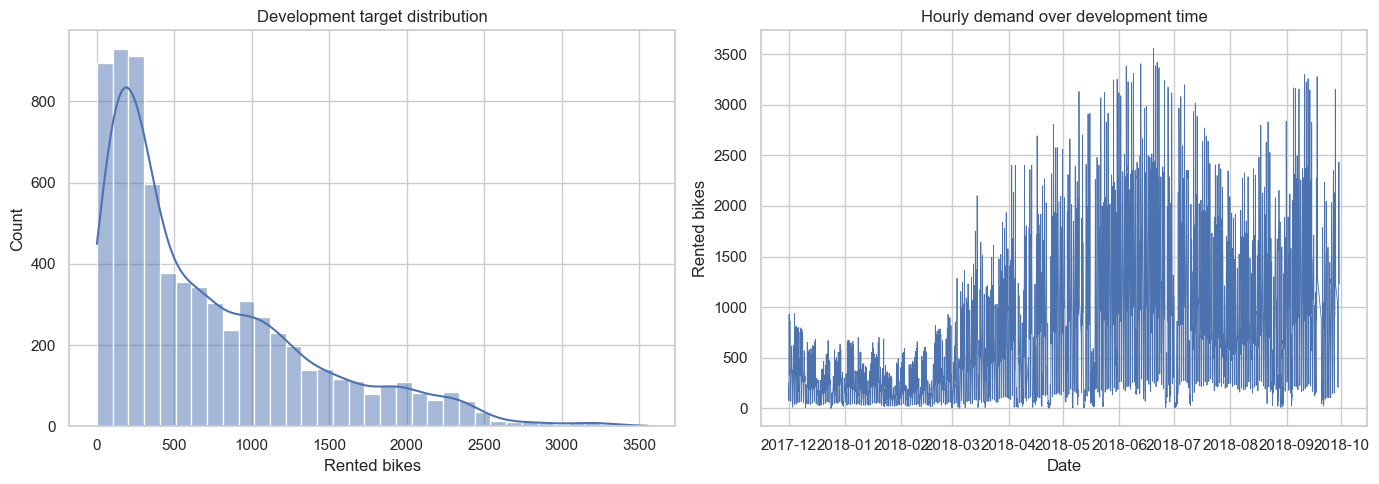

In [14]:
# I do target EDA only on pre-test data, so the final period cannot influence model design.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(development_df["rented_bike_count"], bins=35, kde=True, ax=axes[0])
axes[0].set(title="Development target distribution", xlabel="Rented bikes")

sns.lineplot(data=development_df, x="datetime", y="rented_bike_count",
             estimator=None, linewidth=0.6, ax=axes[1])
axes[1].set(title="Hourly demand over development time", xlabel="Date", ylabel="Rented bikes")
plt.tight_layout()
plt.show()

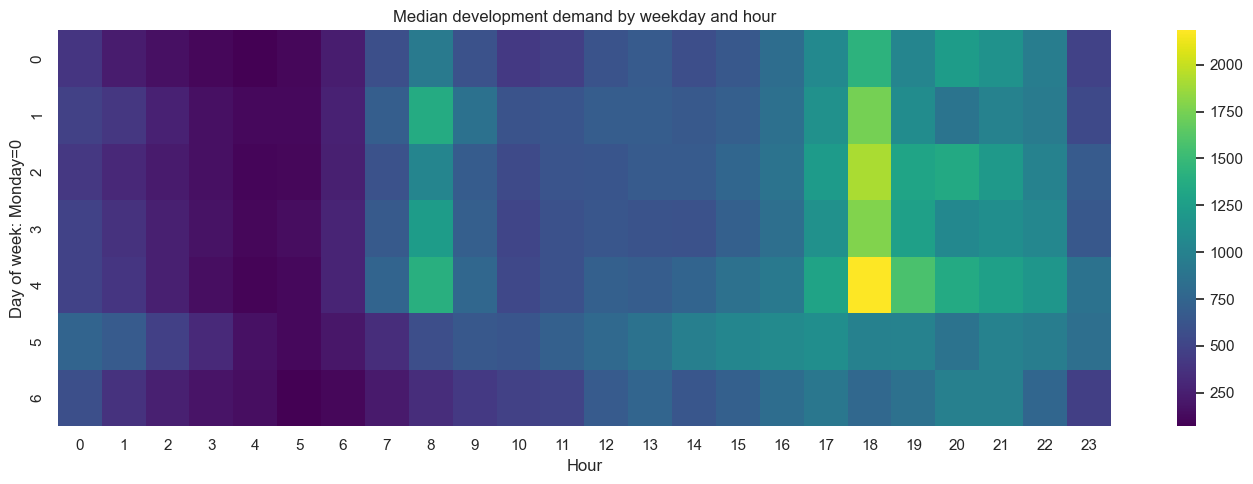

In [15]:
# A weekday-hour heatmap shows why one global hourly curve is not enough: commute patterns change by day.
weekly_demand = development_df.pivot_table(
    index="dayofweek", columns="hour", values="rented_bike_count", aggfunc="median"
)

plt.figure(figsize=(14, 5))
sns.heatmap(weekly_demand, cmap="viridis")
plt.title("Median development demand by weekday and hour")
plt.xlabel("Hour")
plt.ylabel("Day of week: Monday=0")
plt.tight_layout()
plt.show()

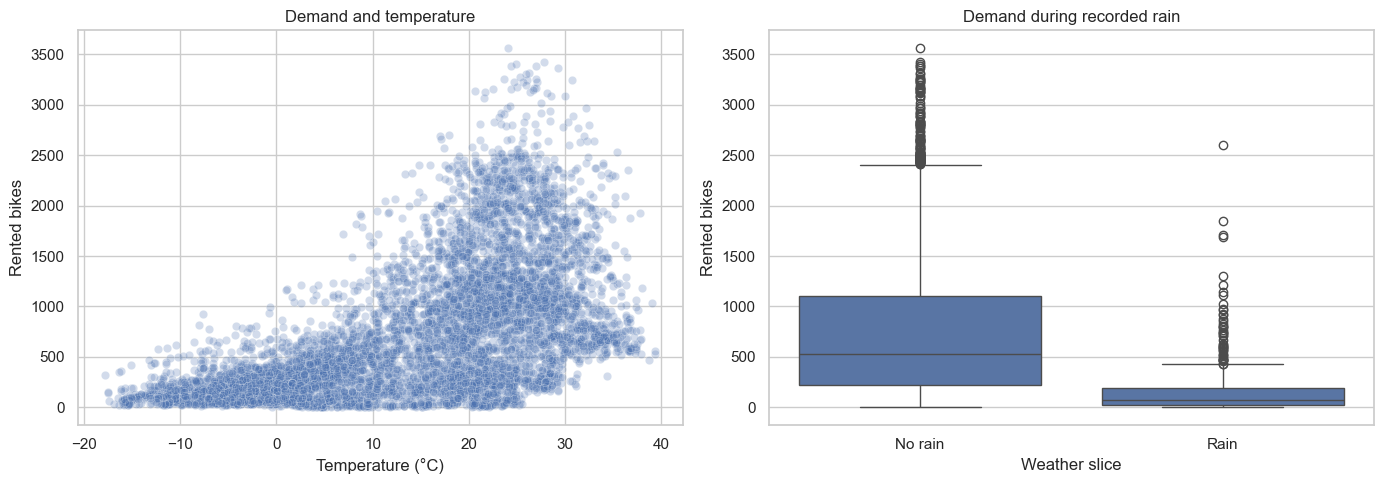

In [16]:
# These plots show association, not causation. Weather and season move together in this one-year dataset.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=development_df, x="temperature_c", y="rented_bike_count",
                alpha=0.25, ax=axes[0])
axes[0].set(title="Demand and temperature", xlabel="Temperature (°C)", ylabel="Rented bikes")

rain_label = np.where(development_df["rainfall_mm"].gt(0), "Rain", "No rain")
sns.boxplot(x=rain_label, y=development_df["rented_bike_count"], ax=axes[1])
axes[1].set(title="Demand during recorded rain", xlabel="Weather slice", ylabel="Rented bikes")
plt.tight_layout()
plt.show()

In [17]:
# Different target levels across time windows are evidence that one random split would be too optimistic.
distribution_rows = []
for fold_name, validation_start, validation_end in folds:
    train_rows = df[df["datetime"] < validation_start]
    validation_rows = df[(df["datetime"] >= validation_start) & (df["datetime"] < validation_end)]
    distribution_rows.append({
        "fold": fold_name,
        "train_target_mean": train_rows["rented_bike_count"].mean(),
        "validation_target_mean": validation_rows["rented_bike_count"].mean(),
        "validation_target_p90": validation_rows["rented_bike_count"].quantile(0.90),
    })

pd.DataFrame(distribution_rows).round(1)

,fold,train_target_mean,validation_target_mean,validation_target_p90
0,Apr-May,298.8,869.6,1881.0
1,Jun-Jul,485.9,1114.3,2243.8
2,Aug-Sep,645.0,968.9,1912.9


<h3><center>Preprocessing and model benchmark</center></h3>

MAE is primary because it is easy to read as “bikes missed per hour.” RMSE makes large peak errors more expensive, R² provides context, and WAPE normalizes total absolute error by total demand. MAPE is not primary because low or zero counts make percentage errors unstable.

I do not remove correlated weather columns based on VIF. VIF is mainly a linear-coefficient diagnostic, Ridge already regularizes, and tree models can use nonlinear interactions. Correlation is handled cautiously later when interpreting feature importance.

In [18]:
# Main candidates use calendar and recorded-weather information, with a representation suited to each learner.
weather_columns = [
    "temperature_c", "humidity_percent", "wind_speed_m_s", "visibility_10m",
    "dew_point_temperature_c", "solar_radiation_mj_m2", "rainfall_mm", "snowfall_cm",
]
base_columns = ["hour"] + weather_columns + ["holiday", "dayofweek", "day_of_year"]
full_columns = base_columns + ["month", "days_since_start", "week_hour", "is_weekend", "humidity_zero"]

linear_numeric_columns = weather_columns + ["day_sin", "day_cos"]
linear_columns = linear_numeric_columns + ["week_hour", "holiday"]

mlp_numeric_columns = ["day_of_year"] + weather_columns
mlp_columns = mlp_numeric_columns + ["hour", "dayofweek", "holiday"]

In [19]:
# Ridge and MLP need learned imputation/scaling inside each training fold. Trees receive their own simpler preparation.
linear_preprocessor = ColumnTransformer(transformers=[
    ("numeric", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler())]), linear_numeric_columns),
    ("schedule", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["week_hour"]),
    ("binary", "passthrough", ["holiday"])])

mlp_preprocessor = ColumnTransformer(transformers=[
    ("numeric", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]), mlp_numeric_columns),
    ("time", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["hour", "dayofweek"]),
    ("binary", "passthrough", ["holiday"]),
])

median_imputer = SimpleImputer(strategy="median", add_indicator=True)

In [20]:
# This small estimator creates a calendar-aware no-history baseline for the same evaluation loop.
class CalendarMedianRegressor(BaseEstimator, RegressorMixin):
    def fit(self, x, y):
        values = pd.DataFrame({"week_hour": x["week_hour"].to_numpy(), "target": np.asarray(y)})
        self.medians_ = values.groupby("week_hour")["target"].median()
        self.global_median_ = float(np.median(y))
        return self

    def predict(self, x):
        return x["week_hour"].map(self.medians_).fillna(self.global_median_).to_numpy()

In [21]:
# I keep the classical and neural models compact. Three hundred trees test the same idea as the old 800-tree models at lower cost.
ridge_model = Pipeline(steps=[
    ("preprocessor", clone(linear_preprocessor)),
    ("model", Ridge(alpha=1.0)),
])

random_forest_model = Pipeline(steps=[
    ("imputer", clone(median_imputer)),
    ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                     random_state=random_state, n_jobs=1)),
])

extra_trees_model = Pipeline(steps=[
    ("imputer", clone(median_imputer)),
    ("model", ExtraTreesRegressor(n_estimators=300, min_samples_leaf=2,
                                   random_state=random_state, n_jobs=1)),
])

mlp_network = Pipeline(steps=[
    ("preprocessor", clone(mlp_preprocessor)),
    ("model", MLPRegressor(hidden_layer_sizes=(128, 64), early_stopping=True,
                           max_iter=600, n_iter_no_change=20, random_state=random_state)),
])
mlp_model = TransformedTargetRegressor(regressor=mlp_network, transformer=StandardScaler())

In [22]:
# The improved HGB adds explicit calendar/trend signals and uses fewer leaves. Only the original low-cardinality fields are categorical.
hgb_categories = ["hour", "dayofweek", "holiday"]

hgb_current = HistGradientBoostingRegressor(
    learning_rate=0.05, max_iter=500, max_leaf_nodes=31, min_samples_leaf=20,
    l2_regularization=1, categorical_features=["hour", "dayofweek", "holiday"],
    early_stopping=False, random_state=random_state,
)

hgb_improved = HistGradientBoostingRegressor(
    learning_rate=0.05, max_iter=500, max_leaf_nodes=15, min_samples_leaf=10,
    l2_regularization=1, categorical_features=hgb_categories,
    early_stopping=False, random_state=random_state,
)

hgb_poisson = HistGradientBoostingRegressor(
    loss="poisson", learning_rate=0.05, max_iter=500, max_leaf_nodes=15, min_samples_leaf=20,
    l2_regularization=1, categorical_features=hgb_categories,
    early_stopping=False, random_state=random_state,
)

models = {
    "Median baseline": (DummyRegressor(strategy="median"), base_columns),
    "Calendar baseline": (CalendarMedianRegressor(), ["week_hour"]),
    "Ridge improved": (ridge_model, linear_columns),
    "Random Forest": (random_forest_model, base_columns),
    "Extra Trees": (extra_trees_model, base_columns),
    "MLP": (mlp_model, mlp_columns),
    "HGB current": (hgb_current, base_columns),
    "HGB improved": (hgb_improved, full_columns),
    "HGB Poisson": (hgb_poisson, full_columns),
}

In [23]:
# Each metric answers a different operational question, so I report them together instead of hiding trade-offs.
def regression_scores(y_true, prediction):
    return {
        "MAE": mean_absolute_error(y_true, prediction),
        "RMSE": root_mean_squared_error(y_true, prediction),
        "R2": r2_score(y_true, prediction),
        "WAPE_percent": 100 * np.abs(y_true - prediction).sum() / np.abs(y_true).sum(),
        "Bias": np.mean(prediction - y_true),
    }

In [24]:
# Every candidate is frozen, trained only on earlier rows, and evaluated on the same three future windows.
fold_rows = []

for model_name, (model, model_columns) in models.items():
    for fold_name, validation_start, validation_end in folds:
        train_rows = df[df["datetime"] < validation_start]
        validation_rows = df[(df["datetime"] >= validation_start) & (df["datetime"] < validation_end)]

        fitted_model = clone(model)
        fit_start = perf_counter()
        fitted_model.fit(train_rows[model_columns], train_rows["rented_bike_count"])
        fit_seconds = perf_counter() - fit_start

        predict_start = perf_counter()
        raw_prediction = fitted_model.predict(validation_rows[model_columns])
        predict_ms_per_1000 = (perf_counter() - predict_start) * 1_000_000 / len(validation_rows)
        prediction = np.clip(raw_prediction, 0, None)

        fold_rows.append({
            "model": model_name, "fold": fold_name,
            **regression_scores(validation_rows["rented_bike_count"], prediction),
            "negative_prediction_percent": 100 * np.mean(raw_prediction < 0),
            "fit_seconds": fit_seconds, "predict_ms_per_1000": predict_ms_per_1000,
        })

fold_results = pd.DataFrame(fold_rows)
print(f"Completed {len(fold_results)} chronological model-fold evaluations.")

Completed 27 chronological model-fold evaluations.


In [25]:
# Mean MAE selects the model; standard deviation shows how much performance changes across time.
benchmark_results = fold_results.groupby("model").agg(
    MAE_mean=("MAE", "mean"),
    MAE_std=("MAE", "std"),
    RMSE_mean=("RMSE", "mean"),
    R2_mean=("R2", "mean"),
    WAPE_mean_percent=("WAPE_percent", "mean"),
    Bias_mean=("Bias", "mean"),
    fit_seconds=("fit_seconds", "mean"),
    predict_ms_per_1000=("predict_ms_per_1000", "mean"),
).sort_values("MAE_mean")

selected_model_name = benchmark_results.index[0]
print(f"Selected by mean chronological MAE: {selected_model_name}")
benchmark_results.round(3)

Selected by mean chronological MAE: HGB improved


,MAE_mean,MAE_std,RMSE_mean,R2_mean,WAPE_mean_percent,Bias_mean,fit_seconds,predict_ms_per_1000
model,,,,,,,,
HGB improved,246.942,89.592,339.911,0.739,25.739,-98.426,0.563,34.949
HGB current,252.977,89.206,345.283,0.733,26.312,-89.461,0.816,44.046
Extra Trees,254.726,75.321,356.536,0.720,26.357,-55.173,1.812,32.044
HGB Poisson,256.136,83.867,361.890,0.708,26.516,-144.078,0.571,34.854
Random Forest,266.723,66.210,372.468,0.696,27.623,-59.997,3.496,28.474
MLP,276.680,68.791,392.800,0.665,28.073,-33.209,1.450,4.067
Ridge improved,426.682,91.394,519.510,0.423,43.236,108.722,0.018,3.541
Calendar baseline,680.645,140.558,861.382,-0.586,69.140,-634.838,0.001,0.348
Median baseline,741.017,107.448,970.191,-1.008,75.355,-686.604,0.001,0.272


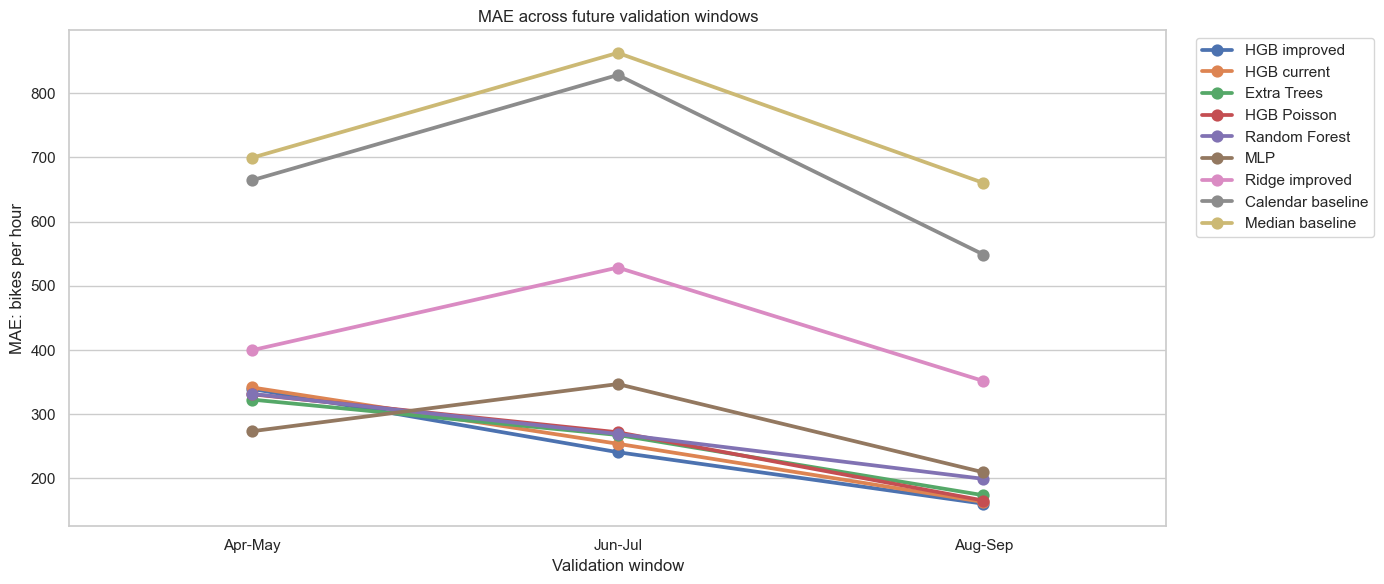

In [26]:
# A fold plot makes temporal instability visible; one average number can hide it.
plt.figure(figsize=(14, 6))
plot_order = benchmark_results.index
sns.pointplot(data=fold_results, x="fold", y="MAE", hue="model", hue_order=plot_order,
              markers="o", linestyles="-")
plt.title("MAE across future validation windows")
plt.xlabel("Validation window")
plt.ylabel("MAE: bikes per hour")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [27]:
# I verify that 300 Extra Trees are close to 800 before keeping the cheaper setting.
latest_train = df[df["datetime"] < "2018-08-01"]
latest_validation = df[(df["datetime"] >= "2018-08-01") & (df["datetime"] < "2018-10-01")]
tree_count_rows = []

for tree_count in [100, 300, 800]:
    model = Pipeline(steps=[
        ("imputer", clone(median_imputer)),
        ("model", ExtraTreesRegressor(n_estimators=tree_count, min_samples_leaf=2,
                                       random_state=random_state, n_jobs=1)),
    ])
    fit_start = perf_counter()
    model.fit(latest_train[base_columns], latest_train["rented_bike_count"])
    prediction = np.clip(model.predict(latest_validation[base_columns]), 0, None)
    tree_count_rows.append({
        "trees": tree_count,
        "MAE": mean_absolute_error(latest_validation["rented_bike_count"], prediction),
        "fit_seconds": perf_counter() - fit_start,
    })

pd.DataFrame(tree_count_rows).round(3)

,trees,MAE,fit_seconds
0,100,177.252,0.854
1,300,173.778,2.483
2,800,175.174,6.681


In [28]:
# This directly measures whether the changes improve the HGB already present in the current notebook.
hgb_comparison = benchmark_results.loc[["HGB current", "HGB improved"], [
    "MAE_mean", "MAE_std", "RMSE_mean", "fit_seconds", "predict_ms_per_1000",
]].copy()
hgb_gain_percent = 100 * (
    hgb_comparison.loc["HGB current", "MAE_mean"]
    - hgb_comparison.loc["HGB improved", "MAE_mean"]
) / hgb_comparison.loc["HGB current", "MAE_mean"]

print(f"Mean chronological MAE improvement: {hgb_gain_percent:.1f}%")
hgb_comparison.round(3)

Mean chronological MAE improvement: 2.4%


,MAE_mean,MAE_std,RMSE_mean,fit_seconds,predict_ms_per_1000
model,,,,,
HGB current,252.977,89.206,345.283,0.816,44.046
HGB improved,246.942,89.592,339.911,0.563,34.949


<h3><center>Which columns matter?</center></h3>

Permutation importance is calculated on the latest validation window, never on training rows. It measures how much this fitted model relies on a column; it does not prove causation. Correlated inputs can share importance, so the following rank is paired with a feature-group ablation. See the [scikit-learn permutation-importance guide](https://scikit-learn.org/stable/modules/permutation_importance.html).

In [29]:
# I fit the selected development model on data before August and inspect it on unseen August-September rows.
selected_model, selected_columns = models[selected_model_name]
importance_model = clone(selected_model).fit(
    latest_train[selected_columns], latest_train["rented_bike_count"]
)

importance_result = permutation_importance(
    importance_model, latest_validation[selected_columns], latest_validation["rented_bike_count"],
    scoring="neg_mean_absolute_error", n_repeats=12, random_state=random_state, n_jobs=1,
)
feature_importance = pd.DataFrame({
    "feature": selected_columns,
    "MAE_increase": importance_result.importances_mean,
    "importance_std": importance_result.importances_std,
}).sort_values("MAE_increase", ascending=False)

feature_importance.round(2)

,feature,MAE_increase,importance_std
0,hour,397.18,11.90
2,humidity_percent,54.19,3.40
7,rainfall_mm,42.72,3.01
1,temperature_c,41.12,1.77
14,week_hour,24.79,1.34
5,dew_point_temperature_c,24.22,1.17
10,dayofweek,12.97,1.48
6,solar_radiation_mj_m2,12.97,1.51
9,holiday,8.37,0.63
3,wind_speed_m_s,2.28,0.51


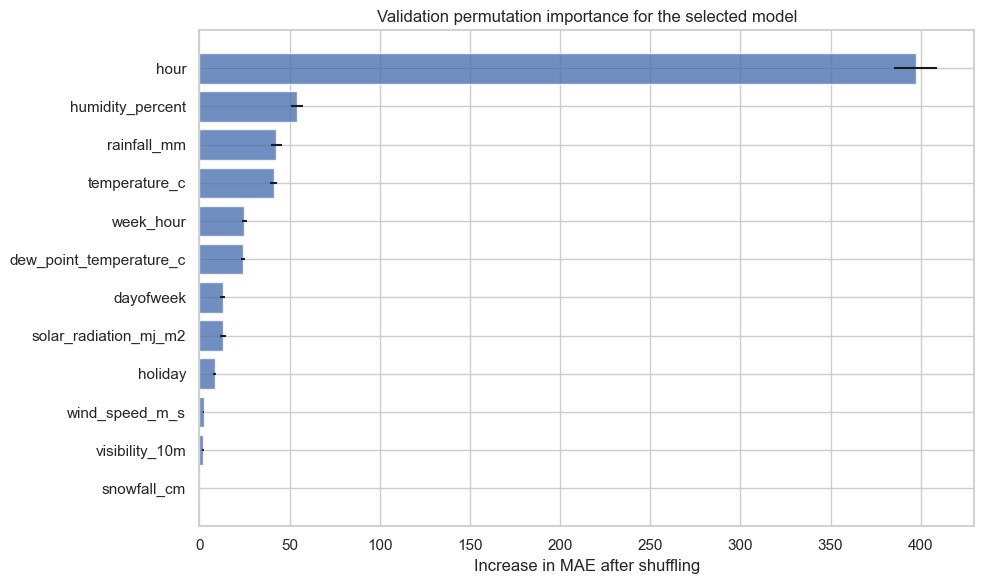

In [30]:
# Larger positive values mean validation MAE becomes worse when that column is shuffled.
plot_importance = feature_importance.head(12).sort_values("MAE_increase")
plt.figure(figsize=(10, 6))
plt.barh(plot_importance["feature"], plot_importance["MAE_increase"],
         xerr=plot_importance["importance_std"], alpha=0.8)
plt.title("Validation permutation importance for the selected model")
plt.xlabel("Increase in MAE after shuffling")
plt.tight_layout()
plt.show()

An extrapolating time feature can show near-zero permutation importance when every future row falls beyond the largest training value and enters the same terminal tree branch. That does not prove the feature had no effect during fitting. This is another reason to read individual importance together with chronological refit results and the group ablation.

In [31]:
# Group ablation asks a safer question: how much do calendar and weather information contribute as groups?
calendar_columns = [
    "hour", "holiday", "dayofweek", "day_of_year", "month",
    "days_since_start", "week_hour", "is_weekend",
]
weather_group_columns = weather_columns + ["humidity_zero"]
feature_groups = {
    "Calendar only": calendar_columns,
    "Weather only": weather_group_columns,
    "Calendar + weather": full_columns,
}

group_rows = []
for group_name, group_columns in feature_groups.items():
    categorical_columns = [column for column in hgb_categories if column in group_columns]
    for fold_name, validation_start, validation_end in folds:
        train_rows = df[df["datetime"] < validation_start]
        validation_rows = df[(df["datetime"] >= validation_start) & (df["datetime"] < validation_end)]
        group_model = HistGradientBoostingRegressor(
            learning_rate=0.05, max_iter=500, max_leaf_nodes=15, min_samples_leaf=10,
            l2_regularization=1, categorical_features=categorical_columns or None,
            early_stopping=False, random_state=random_state,
        )
        group_model.fit(train_rows[group_columns], train_rows["rented_bike_count"])
        prediction = np.clip(group_model.predict(validation_rows[group_columns]), 0, None)
        group_rows.append({
            "feature_group": group_name, "fold": fold_name,
            "MAE": mean_absolute_error(validation_rows["rented_bike_count"], prediction),
        })

group_ablation = pd.DataFrame(group_rows).groupby("feature_group")["MAE"].agg(["mean", "std"])
group_ablation.sort_values("mean").round(2)

,mean,std
feature_group,,
Calendar + weather,246.94,89.59
Calendar only,336.11,49.84
Weather only,430.73,51.88


<h3><center>October-November demonstration test</center></h3>

The model selected from the chronological development folds is now refitted on all development rows and evaluated on October-November. The diagnostics below explain failure modes.

**Audit note:** during creation of this deliverable, this period was inspected while verifying alternative implementations. It is therefore a development-inspected demonstration set, not a pristine external benchmark. A production project should lock the pipeline and collect a new future shadow period.

In [32]:
# This is the demonstration performance estimate for the comparable no-history benchmark.
selected_model, selected_columns = models[selected_model_name]
final_fit_start = perf_counter()
final_model = clone(selected_model).fit(
    development_df[selected_columns], development_df["rented_bike_count"]
)
final_fit_seconds = perf_counter() - final_fit_start

raw_test_prediction = final_model.predict(test_df[selected_columns])
test_prediction = np.clip(raw_test_prediction, 0, None)
test_scores = pd.DataFrame([{
    "model": selected_model_name,
    **regression_scores(test_df["rented_bike_count"], test_prediction),
    "fit_seconds": final_fit_seconds,
    "negative_prediction_percent": 100 * np.mean(raw_test_prediction < 0),
}]).set_index("model")

test_scores.round(3)

,MAE,RMSE,R2,WAPE_percent,Bias,fit_seconds,negative_prediction_percent
model,,,,,,,
HGB improved,148.244,224.442,0.84,17.435,-74.131,0.653,0.228


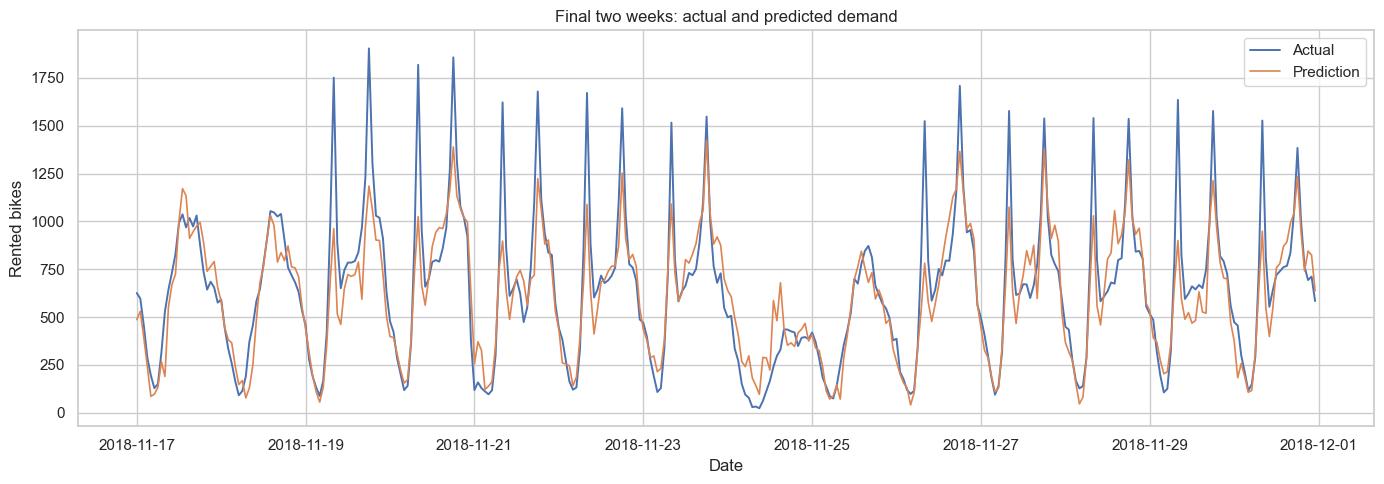

In [33]:
# A short time window checks whether the model follows shape, not only the average score.
test_diagnostics = test_df[[
    "datetime", "rented_bike_count", "hour", "dayofweek", "rainfall_mm", "is_weekend",
]].copy()
test_diagnostics["prediction"] = test_prediction
test_diagnostics["error"] = test_diagnostics["prediction"] - test_diagnostics["rented_bike_count"]
test_diagnostics["absolute_error"] = test_diagnostics["error"].abs()

last_two_weeks = test_diagnostics.tail(24 * 14)
plt.figure(figsize=(14, 5))
plt.plot(last_two_weeks["datetime"], last_two_weeks["rented_bike_count"], label="Actual", linewidth=1.4)
plt.plot(last_two_weeks["datetime"], last_two_weeks["prediction"], label="Prediction", linewidth=1.2)
plt.title("Final two weeks: actual and predicted demand")
plt.xlabel("Date")
plt.ylabel("Rented bikes")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Slice metrics reveal where an acceptable overall score can still hide operationally important errors.
peak_threshold = development_df["rented_bike_count"].quantile(0.90)
slice_masks = {
    "Overall": np.ones(len(test_diagnostics), dtype=bool),
    "Peak demand": test_diagnostics["rented_bike_count"].ge(peak_threshold),
    "Non-peak demand": test_diagnostics["rented_bike_count"].lt(peak_threshold),
    "Rain": test_diagnostics["rainfall_mm"].gt(0),
    "No rain": test_diagnostics["rainfall_mm"].eq(0),
    "Weekend": test_diagnostics["is_weekend"].eq(1),
    "Weekday": test_diagnostics["is_weekend"].eq(0),
    "Rush hours": test_diagnostics["hour"].isin([7, 8, 17, 18]),
}

slice_rows = []
for slice_name, mask in slice_masks.items():
    rows = test_diagnostics.loc[mask]
    slice_rows.append({
        "slice": slice_name, "rows": len(rows),
        "MAE": rows["absolute_error"].mean(),
        "RMSE": np.sqrt(np.mean(rows["error"] ** 2)),
        "Bias": rows["error"].mean(),
    })

slice_results = pd.DataFrame(slice_rows).set_index("slice")
slice_results.round(2)

,rows,MAE,RMSE,Bias
slice,,,,
Overall,1313,148.24,224.44,-74.13
Peak demand,112,461.38,532.92,-453.47
Non-peak demand,1201,119.04,169.08,-38.75
Rain,50,128.46,185.06,64.49
No rain,1263,149.03,225.86,-79.62
Weekend,353,119.27,166.29,-49.01
Weekday,960,158.90,242.34,-83.37
Rush hours,220,339.31,429.42,-291.81


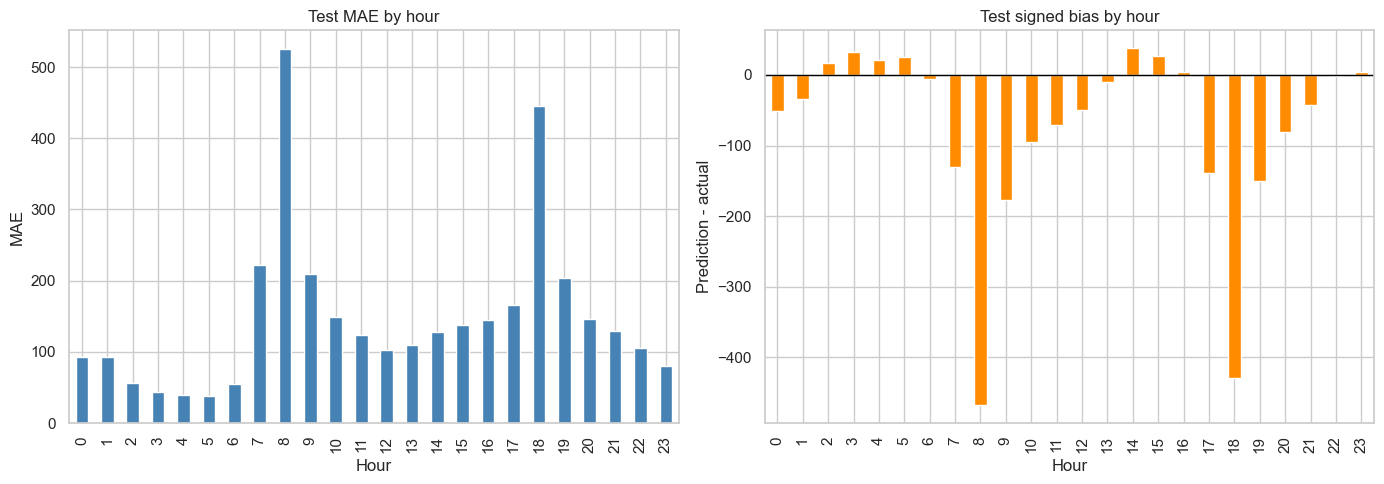

In [35]:
# Hourly MAE and signed bias show when the model misses peaks or systematically over/under-predicts.
hourly_error = test_diagnostics.groupby("hour").agg(
    MAE=("absolute_error", "mean"),
    Bias=("error", "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hourly_error["MAE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set(title="Test MAE by hour", xlabel="Hour", ylabel="MAE")
hourly_error["Bias"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Test signed bias by hour", xlabel="Hour", ylabel="Prediction - actual")
plt.tight_layout()
plt.show()

In [36]:
# Residual autocorrelation is evidence of unused time signal; it does not identify the cause by itself.
residual_series = test_diagnostics.set_index("datetime")["error"].asfreq("h")
residual_autocorrelation = pd.Series({
    "1 hour": residual_series.autocorr(lag=1),
    "24 hours": residual_series.autocorr(lag=24),
    "168 hours": residual_series.autocorr(lag=168),
}, name="residual_autocorrelation")

residual_autocorrelation.round(3)

1 hour       0.572
24 hours     0.564
168 hours    0.493
Name: residual_autocorrelation, dtype: float64

<h3><center>Rolling one-hour extension with a recorded-weather proxy</center></h3>

The previous diagnostics suggest that recent demand is missing. I now add only the previous hour and a trailing 24-hour demand mean. Every rolling prediction may use the actual counts that arrived before it. Recorded same-hour weather remains an oracle proxy for an assumed one-hour weather forecast, so production must use archived one-hour forecasts. The lag logic is valid for one-step online evaluation, but it would leak future information in a fixed-origin multi-step batch forecast.

In [37]:
# The model structure stays fixed so the gain measures new information, not a larger search budget.
history_lag_columns = ["demand_lag_1h", "demand_mean_24h"]
history_columns = full_columns + history_lag_columns
history_model = clone(hgb_improved)
history_fold_rows = []

for fold_name, validation_start, validation_end in folds:
    train_rows = df[df["datetime"] < validation_start].dropna(subset=history_lag_columns)
    validation_rows = df[
        (df["datetime"] >= validation_start) & (df["datetime"] < validation_end)
    ].dropna(subset=history_lag_columns)

    fitted_history_model = clone(history_model).fit(
        train_rows[history_columns], train_rows["rented_bike_count"]
    )
    prediction = np.clip(fitted_history_model.predict(validation_rows[history_columns]), 0, None)
    history_fold_rows.append({
        "fold": fold_name,
        **regression_scores(validation_rows["rented_bike_count"], prediction),
    })

history_fold_results = pd.DataFrame(history_fold_rows)
history_development = development_df.dropna(subset=history_lag_columns)
final_history_model = clone(history_model).fit(
    history_development[history_columns], history_development["rented_bike_count"]
)
history_test_prediction = np.clip(final_history_model.predict(test_df[history_columns]), 0, None)
history_test_scores = regression_scores(test_df["rented_bike_count"], history_test_prediction)

print("Rolling one-hour validation with recorded-weather proxy:")
display(history_fold_results.set_index("fold").round(3))
pd.DataFrame([history_test_scores], index=["One-hour demonstration"]).round(3)

Rolling one-hour validation with recorded-weather proxy:


,MAE,RMSE,R2,WAPE_percent,Bias
fold,,,,,
Apr-May,194.594,307.927,0.796,22.378,-122.952
Jun-Jul,158.011,223.428,0.906,14.180,-15.222
Aug-Sep,88.048,142.144,0.951,9.087,-11.477


,MAE,RMSE,R2,WAPE_percent,Bias
One-hour demonstration,79.863,114.869,0.958,9.393,26.705


In [38]:
# I inspect history importance on August-September, keeping the final test out of interpretation.
history_latest_train = latest_train.dropna(subset=history_lag_columns)
history_importance_model = clone(history_model).fit(
    history_latest_train[history_columns], history_latest_train["rented_bike_count"]
)
history_importance_result = permutation_importance(
    history_importance_model, latest_validation[history_columns], latest_validation["rented_bike_count"],
    scoring="neg_mean_absolute_error", n_repeats=8, random_state=random_state, n_jobs=1,
)
history_importance = pd.DataFrame({
    "feature": history_columns,
    "MAE_increase": history_importance_result.importances_mean,
    "importance_std": history_importance_result.importances_std,
}).sort_values("MAE_increase", ascending=False)

history_importance.head(12).round(2)

,feature,MAE_increase,importance_std
17,demand_lag_1h,494.02,11.57
0,hour,171.12,5.11
6,solar_radiation_mj_m2,24.28,0.56
14,week_hour,16.85,2.10
7,rainfall_mm,16.78,1.51
1,temperature_c,4.46,0.39
2,humidity_percent,3.93,0.69
10,dayofweek,3.70,0.77
4,visibility_10m,1.49,0.23
9,holiday,1.27,0.28


In [39]:
# The two scores are placed side by side only after their different prediction contracts are stated.
contract_comparison = pd.DataFrame([
    {"contract": "Recorded-weather, no history", **test_scores.iloc[0][["MAE", "RMSE", "R2", "WAPE_percent"]].to_dict()},
    {"contract": "Rolling 1h + history + recorded weather", **{key: history_test_scores[key] for key in ["MAE", "RMSE", "R2", "WAPE_percent"]}},
]).set_index("contract")

contract_comparison.round(3)

,MAE,RMSE,R2,WAPE_percent
contract,,,,
"Recorded-weather, no history",148.244,224.442,0.840,17.435
Rolling 1h + history + recorded weather,79.863,114.869,0.958,9.393


<h3><center>Honest conclusions and senior-level interpretation</center></h3>

In [40]:
# These statements are generated from the executed results, so the notebook does not hard-code a favorable story.
main_mae = test_scores.iloc[0]["MAE"]
history_mae = history_test_scores["MAE"]
peak_mae = slice_results.loc["Peak demand", "MAE"]
peak_bias = slice_results.loc["Peak demand", "Bias"]
top_features = ", ".join(feature_importance.head(5)["feature"])

print(f"1. The selected comparable model is {selected_model_name}; demonstration MAE is {main_mae:.1f} bikes per hour.")
print(f"2. Its five largest validation reliance signals are: {top_features}.")
print(f"3. Peak-demand MAE is {peak_mae:.1f}; peak signed bias is {peak_bias:.1f} bikes.")
print(f"4. With rolling one-hour history and the recorded-weather proxy, demonstration MAE is {history_mae:.1f} bikes per hour.")
print("5. Therefore model capacity is not the only ceiling: recent-demand availability matters strongly under the rolling one-hour contract.")

1. The selected comparable model is HGB improved; demonstration MAE is 148.2 bikes per hour.
2. Its five largest validation reliance signals are: hour, humidity_percent, rainfall_mm, temperature_c, week_hour.
3. Peak-demand MAE is 461.4; peak signed bias is -453.5 bikes.
4. With rolling one-hour history and the recorded-weather proxy, demonstration MAE is 79.9 bikes per hour.
5. Therefore model capacity is not the only ceiling: recent-demand availability matters strongly under the rolling one-hour contract.


### What prevents a stronger real-world claim?

- There is only one annual cycle. We cannot prove that seasonal behavior repeats next year.
- The source has no station ID, inventory, capacity, maintenance, event, transit, or spatial features. It cannot support station-level rebalancing claims.
- Recorded same-hour weather is optimistic for advance forecasting. Production evaluation needs archived weather forecasts generated at the correct issue time.
- High-demand hours are operationally important observations, not noise to delete. Slice metrics show whether the model under-serves these peaks.
- Temperature, humidity, and dew point are related. Individual permutation ranks describe model reliance, not independent causal effects.
- The MLP is a tabular neural baseline. It is not an LSTM and does not receive sequences in the comparable benchmark.
- Its internal early-stopping subset is random but drawn only from past training rows. The outer evaluation remains chronological; a production neural workflow should use a time-ordered stopping window.

### Real-work deployment plan

1. Validate raw schema, hourly continuity, category values, and missingness at ingestion.
2. Route known closures to zero, then use the demand model only on functioning hours.
3. Store the exact forecast issue time and use only features available then.
4. Track MAE, peak bias, rain/rush-hour slices, feature drift, model age, fit time, and inference latency.
5. Retrain on a schedule only after collecting multiple seasons; keep a recent chronological champion/challenger test.

Google’s production guidance stresses feature availability, schema checks, training-serving consistency, and slice monitoring: [Production ML systems, updated 2025](https://developers.google.com/machine-learning/crash-course/production-ml-systems/monitoring).

### Why this is a stronger 2025-2026 portfolio project

The defensible story is not “I tried many algorithms.” It is: I defined the prediction moment, protected future data, built strong baselines, measured runtime, improved an existing model across chronological windows, inspected column and group value, diagnosed peak errors, and showed how feature availability changes the result.

For the repository, add a short README containing the business question, the two contracts, the main result, the run command, environment versions, and limitations. GitHub’s job-search guidance says reviewers may inspect projects only briefly and recommends highlighting a small number of strong projects: [GitHub Docs](https://docs.github.com/en/account-and-profile/tutorials/using-your-github-profile-to-enhance-your-resume). The [World Economic Forum Future of Jobs Report 2025](https://www.weforum.org/publications/the-future-of-jobs-report-2025/in-full/3-skills-outlook/) identifies analytical thinking and AI/big-data skills as important; this notebook demonstrates both through decisions and evidence rather than visual decoration.

### Main sources

- UCI dataset and license: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand
- Original associated study: https://doi.org/10.1016/j.comcom.2020.02.007
- Time-aware splitting: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- Leakage-safe pipelines: https://scikit-learn.org/stable/common_pitfalls.html
- Bike time-feature engineering: https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html
- Proper lagged forecasting evaluation: https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html
- Permutation importance and correlated-feature warning: https://scikit-learn.org/stable/modules/permutation_importance.html
- Production monitoring and training-serving skew: https://developers.google.com/machine-learning/crash-course/production-ml-systems/monitoring

In [41]:
# Final checks make sure the delivered notebook finished with valid, nonnegative, aligned predictions.
assert len(test_prediction) == len(test_df)
assert len(history_test_prediction) == len(test_df)
assert np.isfinite(test_prediction).all() and np.isfinite(history_test_prediction).all()
assert (test_prediction >= 0).all() and (history_test_prediction >= 0).all()
assert selected_model_name == benchmark_results.index[0]

print("All final reproducibility checks passed.")

All final reproducibility checks passed.
